In [27]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import os

print("🚀 AQI Project Started")

🚀 AQI Project Started


In [28]:
file_path = "data/processed/DELHI_MASTER_AQI_WEATHER_2025.csv"

df = pd.read_csv(file_path)

print("✅ Data Loaded")
print("Shape:", df.shape)
df.head()

✅ Data Loaded
Shape: (144648, 27)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,station,latitude,...,rain_mm,wind_speed_ms,wind_dir_deg,wind_gust_ms,solar_ghi_wm2,solar_direct_wm2,solar_diffuse_wm2,cloud_cover_pct,visibility_m,vpd_kpa
0,2025-01-01 00:00:00,2025-01-01,2025,1,1,0,2,0,Alipur,28.798600,...,0.0,0.79,305,1.8,0.0,0.0,0.0,98,NaN,0.0
1,2025-01-01 00:00:00,2025-01-01,2025,1,1,0,2,0,Bawana,28.623000,...,0.0,0.51,281,0.9,0.0,0.0,0.0,100,NaN,0.0
2,2025-01-01 00:00:00,2025-01-01,2025,1,1,0,2,0,Burari,28.716700,...,0.0,0.79,288,2.0,0.0,0.0,0.0,100,NaN,0.0
3,2025-01-01 00:00:00,2025-01-01,2025,1,1,0,2,0,DRKARNISINGH,28.498571,...,0.0,1.14,293,2.3,0.0,0.0,0.0,9,NaN,0.0
4,2025-01-01 00:00:00,2025-01-01,2025,1,1,0,2,0,DTU,28.750049,...,0.0,0.79,305,1.8,0.0,0.0,0.0,98,NaN,0.0


In [29]:
# Drop useless column if exists
if "visibility_m" in df.columns:
    df = df.drop(columns=["visibility_m"])

# Convert datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Sort properly
df = df.sort_values(by=["station", "datetime"]).reset_index(drop=True)

print("✅ Data Cleaned")
print("Shape:", df.shape)

✅ Data Cleaned
Shape: (144648, 26)


In [30]:
print("⏳ Creating lag features...")

df["aqi_lag_1"] = df.groupby("station")["aqi"].shift(1)
df["aqi_lag_2"] = df.groupby("station")["aqi"].shift(2)
df["aqi_lag_3"] = df.groupby("station")["aqi"].shift(3)
df["aqi_lag_24"] = df.groupby("station")["aqi"].shift(24)

# Rolling feature (very useful)
df["aqi_roll_mean_6"] = df.groupby("station")["aqi"].rolling(6).mean().reset_index(0, drop=True)

print("Lag features added")

⏳ Creating lag features...
Lag features added


In [31]:
df = df.dropna().reset_index(drop=True)

print("✅ After dropna")
print("Shape:", df.shape)

✅ After dropna
Shape: (144240, 31)


In [32]:
X = df.drop(columns=[
    "aqi",
    "datetime",
    "date",
    "station"
])

y = df["aqi"]

print("✅ Features ready")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Features ready
X shape: (144240, 27)
y shape: (144240,)


In [33]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("📊 Train size:", X_train.shape)
print("📊 Test size:", X_test.shape)

📊 Train size: (115392, 27)
📊 Test size: (28848, 27)


In [34]:
print("🧠 Training model...")

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Training complete")

🧠 Training model...
✅ Training complete


In [35]:
print("📈 Evaluating...")

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("\n====== 📊 MODEL PERFORMANCE ======")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

📈 Evaluating...

====== 📊 MODEL PERFORMANCE ======
MAE  : 2.72
RMSE : 6.25
R²   : 0.9970


In [36]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/xgboost_aqi_model.pkl")

print("💾 Model saved")

💾 Model saved


<Figure size 1000x600 with 0 Axes>

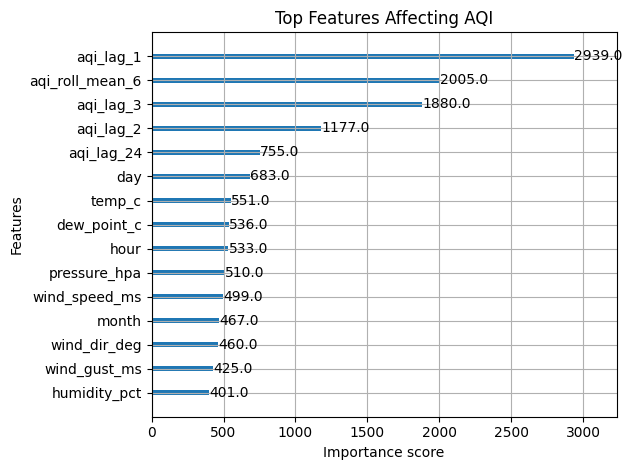

In [37]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=15)
plt.title("Top Features Affecting AQI")
plt.tight_layout()
plt.show()